# MetaLore: Smart City Wireless Network Simulator

A Gymnasium-compatible reinforcement learning environment for simulating wireless networks with base stations, user equipment (UEs), and IoT sensors.

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv, MultiCellEnv
from metalore.config import default_config, small_config, large_config, multi_cell_config

print("MetaLore imported successfully!")

MetaLore imported successfully!


## 2. Environment Configurations

MetaLore provides several pre-configured environments:
- **small**: Minimal setup for quick testing
- **default**: Standard single-cell configuration
- **large**: Larger scale with more entities
- **multi_cell**: Multiple base stations for complex scenarios

In [2]:
# Compare environment configurations
configs = {
    'small': (SingleCellEnv, small_config()),
    'default': (SingleCellEnv, default_config()),
    'large': (SingleCellEnv, large_config()),
    'multi_cell': (MultiCellEnv, multi_cell_config()),
}

rows = []
for name, (EnvClass, config) in configs.items():
    env = EnvClass(config=config)
    env.reset()
    rows.append({
        'Config': name,
        'BSs': env.num_bs,
        'UEs': env.num_ues,
        'Sensors': env.num_sensors,
        'Width': env.width,
        'Height': env.height,
        'Max Steps': env.EP_MAX_TIME,
    })
    env.close()

config_df = pd.DataFrame(rows)
ipd.display(config_df)

,Config,BSs,UEs,Sensors,Width,Height,Max Steps
0,small,1,5,8,200.0,200.0,100
1,default,1,3,3,200.0,200.0,100
2,large,1,20,10,200.0,200.0,100
3,multi_cell,3,15,20,200.0,200.0,100


## 3. Running the Simulation

The environment follows the standard Gymnasium API:
- `reset()` - Initialize/reset the environment
- `step(action)` - Take an action and advance simulation
- `render()` - Visualize current state

In [3]:
# Create environment
env = MultiCellEnv(config=multi_cell_config())
obs, info = env.reset()

print("="*60)
print("ENVIRONMENT SETUP")
print("="*60)
print(f"Base Stations: {env.num_bs}")
print(f"User Equipment: {env.num_ues}")
print(f"Sensors: {env.num_sensors}")
print(f"Area: {env.width} x {env.height}")
print(f"Max Steps: {env.EP_MAX_TIME}")
print()
print("="*60)
print("RL INTERFACE")
print("="*60)
print(f"Action Space: {env.action_space}")
print(f"Observation Space: {env.observation_space}")
print(f"Initial Observation Shape: {obs.shape}")

ENVIRONMENT SETUP
Base Stations: 3
User Equipment: 15
Sensors: 20
Area: 200.0 x 200.0
Max Steps: 100

RL INTERFACE
Action Space: Box(0.0, 1.0, (2,), float32)
Observation Space: Box(0.0, 10000.0, (2,), float32)
Initial Observation Shape: (2,)


Completed 20 steps
Total Reward: 20.00
Mean Reward: 1.0000


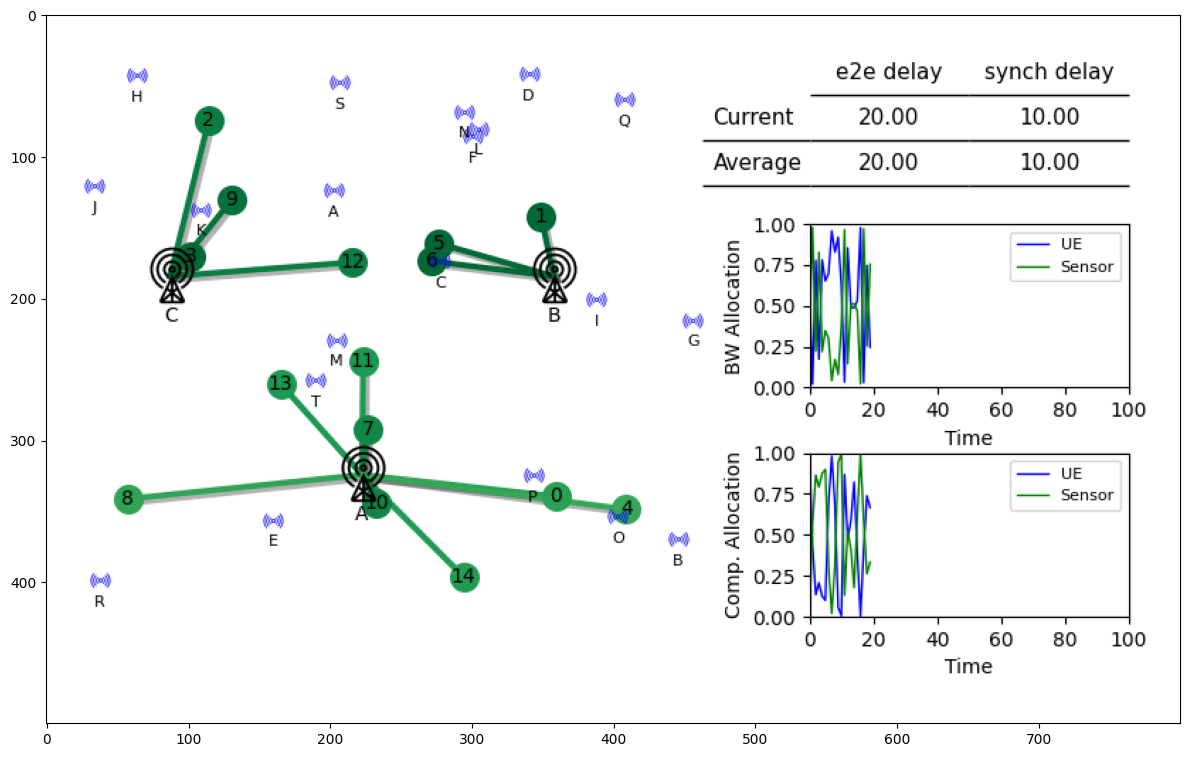

In [ ]:
# Run simulation for N steps
N_STEPS = 100

rewards = []
observations = []

for step in range(N_STEPS):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    rewards.append(reward)
    observations.append(obs)
    
    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break

    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

# Show final frame (persists after loop)
ipd.clear_output(wait=True)
print(f"Completed {len(rewards)} steps")
print(f"Total Reward: {sum(rewards):.2f}")
print(f"Mean Reward: {np.mean(rewards):.4f}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(env.render())
plt.tight_layout()
plt.show()


## 4. Metrics Analysis

The `MetricsTracker` records detailed simulation data at each timestep.

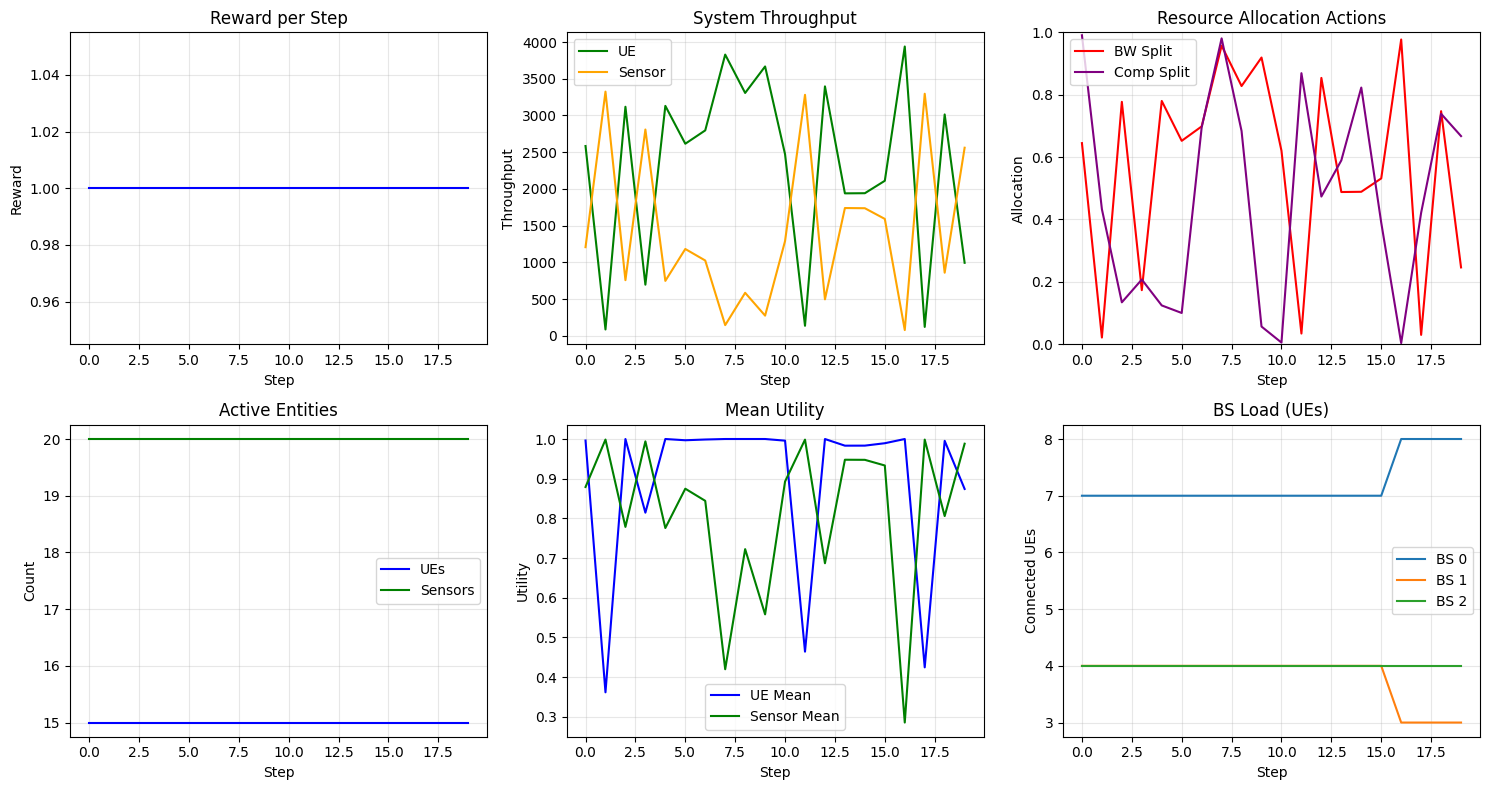

In [5]:
metrics = env.metrics

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Reward over time
ax = axes[0, 0]
ax.plot(metrics.actions['reward'], 'b-', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Reward')
ax.set_title('Reward per Step')
ax.grid(True, alpha=0.3)

# Throughput over time
ax = axes[0, 1]
ax.plot(metrics.environment['throughput_ue'], 'g-', label='UE', linewidth=1.5)
ax.plot(metrics.environment['throughput_sensor'], 'orange', label='Sensor', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Throughput')
ax.set_title('System Throughput')
ax.legend()
ax.grid(True, alpha=0.3)

# Actions over time
ax = axes[0, 2]
ax.plot(metrics.actions['bw_split'], 'r-', label='BW Split', linewidth=1.5)
ax.plot(metrics.actions['comp_split'], 'purple', label='Comp Split', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Allocation')
ax.set_title('Resource Allocation Actions')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Active entities over time
ax = axes[1, 0]
ax.plot(metrics.environment['num_active_ues'], 'b-', label='UEs', linewidth=1.5)
ax.plot(metrics.environment['num_active_sensors'], 'g-', label='Sensors', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Count')
ax.set_title('Active Entities')
ax.legend()
ax.grid(True, alpha=0.3)

# Mean utility over time
ax = axes[1, 1]
util_ue_df = pd.DataFrame(dict(metrics.performance['utilities_ue']))
util_sensor_df = pd.DataFrame(dict(metrics.performance['utilities_sensor']))
if not util_ue_df.empty:
    ax.plot(util_ue_df.mean(axis=1), 'b-', label='UE Mean', linewidth=1.5)
if not util_sensor_df.empty:
    ax.plot(util_sensor_df.mean(axis=1), 'g-', label='Sensor Mean', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Utility')
ax.set_title('Mean Utility')
ax.legend()
ax.grid(True, alpha=0.3)

# BS Load
ax = axes[1, 2]
bs_load_df = pd.DataFrame(metrics.topology['bs_load_ue'])
for col in bs_load_df.columns:
    ax.plot(bs_load_df[col], label=f'BS {col}', linewidth=1.5)
ax.set_xlabel('Step')
ax.set_ylabel('Connected UEs')
ax.set_title('BS Load (UEs)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Detailed Metrics Tables

Raw data for each timestep.

In [6]:
# Environment Summary
print("ENVIRONMENT & THROUGHPUT")
env_df = pd.DataFrame({
    'Time': metrics.environment['time'],
    'Active UEs': metrics.environment['num_active_ues'],
    'Active Sensors': metrics.environment['num_active_sensors'],
    'Throughput UE': [f"{x:.1f}" for x in metrics.environment['throughput_ue']],
    'Throughput Sensor': [f"{x:.1f}" for x in metrics.environment['throughput_sensor']],
})
ipd.display(env_df)

# Actions & Reward
print("\nACTIONS & REWARD")
actions_df = pd.DataFrame({
    'BW Split': [f"{x:.3f}" for x in metrics.actions['bw_split']],
    'Comp Split': [f"{x:.3f}" for x in metrics.actions['comp_split']],
    'Reward': [f"{x:.4f}" for x in metrics.actions['reward']],
})
ipd.display(actions_df)

ENVIRONMENT & THROUGHPUT


,Time,Active UEs,Active Sensors,Throughput UE,Throughput Sensor
0,0.0,15,20,2583.9,1206.8
1,1.0,15,20,85.9,3324.8
2,2.0,15,20,3118.6,757.3
3,3.0,15,20,695.9,2808.7
4,4.0,15,20,3130.6,747.5
5,5.0,15,20,2615.1,1181.9
6,6.0,15,20,2796.9,1025.1
7,7.0,15,20,3829.1,145.1
8,8.0,15,20,3306.6,585.1
9,9.0,15,20,3667.3,274.4



ACTIONS & REWARD


,BW Split,Comp Split,Reward
0,0.645,0.991,1.0000
1,0.021,0.433,1.0000
2,0.777,0.134,1.0000
3,0.173,0.207,1.0000
4,0.780,0.124,1.0000
5,0.652,0.100,1.0000
6,0.698,0.695,1.0000
7,0.957,0.981,1.0000
8,0.828,0.684,1.0000
9,0.919,0.057,1.0000


In [7]:
# Per-Entity Performance
print("UE UTILITIES (per entity, per timestep)")
util_ue = pd.DataFrame(dict(metrics.performance['utilities_ue']))
util_ue.columns = [f'UE {c}' for c in util_ue.columns]
ipd.display(util_ue.round(3))

print("\nUE DATARATES")
macro_ue = pd.DataFrame(dict(metrics.performance['utilities_ue']))
macro_ue.columns = [f'UE {c}' for c in macro_ue.columns]
ipd.display(macro_ue.round(2))

UE UTILITIES (per entity, per timestep)


,UE 0,UE 1,UE 2,UE 3,UE 4,UE 5,UE 6,UE 7,UE 8,UE 9,UE 10,UE 11,UE 12,UE 13,UE 14
0,0.983,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.960,1.000,1.000,1.000,1.000,1.000,1.000
1,0.244,0.436,0.377,0.571,0.335,0.418,0.399,0.388,0.221,0.419,0.345,0.314,0.377,0.297,0.282
2,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
3,0.699,0.893,0.832,1.000,0.789,0.873,0.855,0.839,0.676,0.874,0.802,0.766,0.831,0.750,0.735
4,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
5,0.988,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.965,1.000,1.000,1.000,1.000,1.000,1.000
6,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.981,1.000,1.000,1.000,1.000,1.000,1.000
7,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
8,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
9,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000



UE DATARATES


,UE 0,UE 1,UE 2,UE 3,UE 4,UE 5,UE 6,UE 7,UE 8,UE 9,UE 10,UE 11,UE 12,UE 13,UE 14
0,0.98,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.96,1.00,1.00,1.00,1.00,1.00,1.00
1,0.24,0.44,0.38,0.57,0.34,0.42,0.40,0.39,0.22,0.42,0.35,0.31,0.38,0.30,0.28
2,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
3,0.70,0.89,0.83,1.00,0.79,0.87,0.85,0.84,0.68,0.87,0.80,0.77,0.83,0.75,0.74
4,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
5,0.99,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.97,1.00,1.00,1.00,1.00,1.00,1.00
6,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.98,1.00,1.00,1.00,1.00,1.00,1.00
7,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
8,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
9,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## 6. Episode Summary

In [8]:
# Episode statistics
print("="*60)
print("EPISODE SUMMARY")
print("="*60)
print(f"Total Steps: {metrics.num_steps}")
print(f"Total Reward: {sum(metrics.actions['reward']):.4f}")
print(f"Mean Reward: {np.mean(metrics.actions['reward']):.4f}")
print()
print(f"Mean UE Throughput: {np.mean(metrics.environment['throughput_ue']):.2f}")
print(f"Mean Sensor Throughput: {np.mean(metrics.environment['throughput_sensor']):.2f}")
print()
print(f"Mean BW Split: {np.mean(metrics.actions['bw_split']):.3f}")
print(f"Mean Comp Split: {np.mean(metrics.actions['comp_split']):.3f}")
print()

# Utility statistics
util_ue_all = [v for vals in metrics.performance['utilities_ue'].values() for v in vals]
util_sensor_all = [v for vals in metrics.performance['utilities_sensor'].values() for v in vals]
print(f"Mean UE Utility: {np.mean(util_ue_all):.4f}")
print(f"Mean Sensor Utility: {np.mean(util_sensor_all):.4f}")

# Cleanup
env.close()
print("\nEnvironment closed.")

EPISODE SUMMARY
Total Steps: 20
Total Reward: 20.0000
Mean Reward: 1.0000

Mean UE Throughput: 2294.67
Mean Sensor Throughput: 1449.32

Mean BW Split: 0.573
Mean Comp Split: 0.469

Mean UE Utility: 0.8939
Mean Sensor Utility: 0.8164

Environment closed.
